# 付録. CPU vs GPU — どこで GPU が効くか

## この付録で分かること

- GPU が速いのは **大きな並列計算**(大行列積・大バッチ学習)であること
- 小さな演算では **オーバーヘッド**(起動・転送)で GPU が遅くなりうること
- 正しい計測の作法(**ウォームアップ** と **CUDA 同期**)
- バッチサイズ・行列サイズに対する **スピードアップ** の見方

本編の Notebook は再現性のため CPU 実行で出力を固定しています。
この付録は例外で、**実機の GPU を使って実際の速度差を測ります**。

> **注意 1(ハードウェア依存)**: 以下の数値はこのマシン固有のものです(GPU の有無・機種・CPU で大きく変わります)。
> GPU が無い環境では CPU のみの結果になり、ノートブックはそのまま最後まで実行できます。
>
> **注意 2(並行負荷依存)**: CPU 側の時間は、計測中に動いている **他のプロセスの負荷** に影響されます。
> ここでは安定した代表値を得るため CPU スレッド数を抑え(下のセル)、各計測は複数試行の最小値を取っています。
> それでも厳密な数値が必要なときは、マシンを空けてから
> `jupyter nbconvert --to notebook --execute --inplace notebooks/11_appendix_cpu_vs_gpu.ipynb`
> で再生成してください。GPU 側は CPU 負荷の影響を受けません。

```{admonition} 核心 — ひとことで
:class: tip
**GPU は「同じ演算を大量データに一斉適用する」装置。大きな行列積・大バッチ・半精度ほど効く。**
小さな演算では起動・転送のオーバーヘッドが勝ち、CPU の方が速いことも多い（損益分岐は数百次元あたり）。
正しい計測には**ウォームアップ**と **CUDA 同期** が必須 — 同期忘れは実際よりずっと速い嘘の数値を出す。
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from nn_textbook import benchmark, plotting
from nn_textbook.training import set_seed

set_seed(0)
np.set_printoptions(precision=3, suppress=True)

# Cap CPU threads so tiny ops are not dominated by 20-thread dispatch overhead.
# This gives a stable, representative CPU baseline (most machines have far fewer
# than 20 cores anyway). The GPU timings are unaffected by this setting.
CPU_THREADS = 8
torch.set_num_threads(CPU_THREADS)

devices = benchmark.available_devices()
print("benchmarking devices:")
for d in devices:
    print(f"  {d:5s} -> {benchmark.device_label(d)}")
print(f"\nCPU threads used for timing: {torch.get_num_threads()}")
if "cuda" not in devices:
    print("\n(no GPU detected: this notebook will show CPU-only results)")

benchmarking devices:
  cpu   -> CPU
  cuda  -> GPU (NVIDIA GeForce RTX 5080)

CPU threads used for timing: 8


## 1. なぜ GPU は速い(ことがある)のか

- **CPU**: 少数(数〜数十)の強力なコアで、逐次・低遅延の処理が得意
- **GPU**: 数千の小さなコアで、**同じ演算を大量データに一斉適用**するのが得意

ニューラルネットの計算は行列積が中心で、これは「大量の積和を並列に」やる典型です。
だから **大きい** 行列・**大きい** バッチほど GPU が有利になります。
逆に小さい演算では、GPU を起動しデータを送る固定費(オーバーヘッド)が勝ってしまいます。

計測の作法も大事です。GPU の時間を正しく測るには 2 つの処理が要ります
(`nn_textbook.benchmark.time_callable` が内部で行っています)。

1. **ウォームアップ**: 最初の CUDA 呼び出しはカーネルの初期化など一度きりのコストを払う。計測前に数回空回しする。
2. **同期 (synchronize)**: CUDA カーネルは **非同期** に起動される。`torch.cuda.synchronize()` で完了を待たないと、
   タイマーが仕事の終わる前に止まってしまう。

これを怠ると「GPU が異常に速い」という誤った結果が出ます(末尾の §7 で実演)。

## 2. 行列積のスケーリング

行列サイズ $n \times n$ を変えながら CPU と GPU で行列積を計測します。
小さい $n$ では CPU が勝ち、大きい $n$ で GPU が圧倒する **クロスオーバー** が見えるはずです。

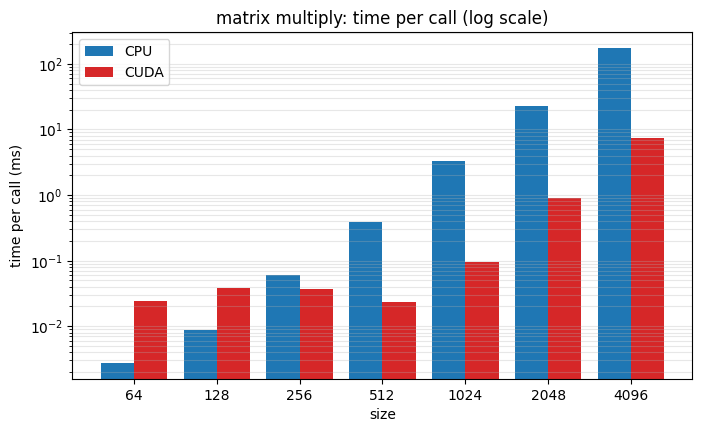

  cpu   n=   64:    0.0027 ms
  cpu   n=  128:    0.0089 ms
  cpu   n=  256:    0.0609 ms
  cpu   n=  512:    0.3904 ms
  cpu   n= 1024:    3.3322 ms
  cpu   n= 2048:   22.7104 ms
  cpu   n= 4096:  175.1480 ms
  cuda  n=   64:    0.0239 ms
  cuda  n=  128:    0.0378 ms
  cuda  n=  256:    0.0370 ms
  cuda  n=  512:    0.0232 ms
  cuda  n= 1024:    0.0942 ms
  cuda  n= 2048:    0.8876 ms
  cuda  n= 4096:    7.4655 ms


In [2]:
# Benchmark matmul across a range of sizes on every available device.
sizes = [64, 128, 256, 512, 1024, 2048, 4096]
matmul_records = benchmark.benchmark_matmul(sizes, devices=devices)

plotting.plot_benchmark(matmul_records, x_key="size",
                        title="matrix multiply: time per call (log scale)")
plt.show()

for r in matmul_records:
    print(f"  {r['device']:5s} n={r['size']:>5}: {r['ms']:9.4f} ms")

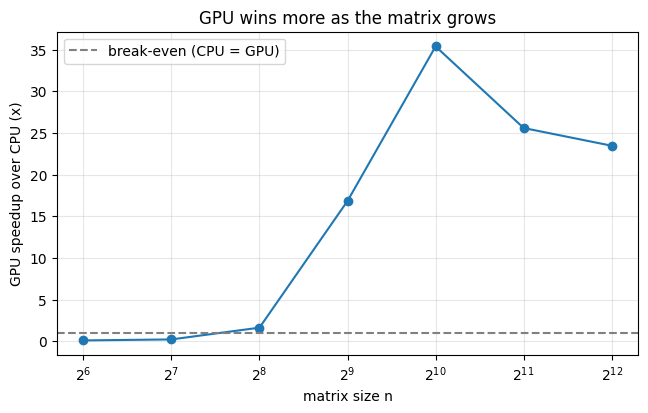

speedup by size (< 1x means CPU is faster):
  n=   64:    0.11x
  n=  128:    0.23x
  n=  256:    1.64x
  n=  512:   16.84x
  n= 1024:   35.37x
  n= 2048:   25.59x
  n= 4096:   23.46x


In [3]:
# Speedup of GPU over CPU as the matrix grows.
table = benchmark.speedup_table(matmul_records, x_key="size")
if "cuda" in devices:
    sizes_arr = [row["size"] for row in table]
    speedups = [row["speedup"] for row in table]
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.plot(sizes_arr, speedups, "o-")
    ax.axhline(1.0, color="gray", ls="--", label="break-even (CPU = GPU)")
    ax.set_xscale("log", base=2)
    ax.set_xlabel("matrix size n"); ax.set_ylabel("GPU speedup over CPU (x)")
    ax.set_title("GPU wins more as the matrix grows"); ax.grid(alpha=0.3); ax.legend()
    plt.show()
    print("speedup by size (< 1x means CPU is faster):")
    for row in table:
        s = row["speedup"]
        print(f"  n={row['size']:>5}: {s:7.2f}x" if s else f"  n={row['size']:>5}: n/a")
else:
    print("no GPU: speedup table is CPU-only")
    for row in table:
        print(f"  n={row['size']:>5}: cpu={row['cpu_ms']:.4f} ms")

小さい行列では GPU のスピードアップが 1 倍未満、つまり **CPU の方が速い**(オーバーヘッドが勝つ)。
サイズが大きくなるほど並列度が活き、GPU が逆転して大差をつけていきます。
クロスオーバー(損益分岐)は数百次元あたりに現れます。

さらに大きい行列(8192)でも GPU は伸び続けます(メモリの許す限り)。

In [4]:
# Push the size further: 8192 x 8192 (~0.8 GB for the three fp32 matrices).
big = benchmark.benchmark_matmul([4096, 8192], devices=devices, n_iters=5)
for row in benchmark.speedup_table(big, x_key="size"):
    if "speedup" in row and row["speedup"]:
        print(f"  n={row['size']:>5}: cpu={row['cpu_ms']:9.2f} ms  gpu={row['gpu_ms']:7.2f} ms  "
              f"speedup={row['speedup']:6.1f}x")
    else:
        print(f"  n={row['size']:>5}: cpu={row['cpu_ms']:9.2f} ms")

  n= 4096: cpu=   167.87 ms  gpu=   4.78 ms  speedup=  35.2x
  n= 8192: cpu=  1348.16 ms  gpu=  73.03 ms  speedup=  18.5x


## 3. 半精度(float16)— GPU をさらに速くする

GPU には fp16/bf16 を高速処理する **Tensor Core** が載っており、
精度を半分にすると行列積はさらに速くなります(メモリも半分)。
混合精度学習(AMP)が標準になっている理由です。
CPU の fp16 は最適化されていないため、ここでは GPU のみ比較します。

In [5]:
# float32 vs float16 matmul on the GPU (Tensor Cores at work).
if "cuda" in devices:
    for dt, name in [(torch.float32, "float32"), (torch.float16, "float16")]:
        recs = benchmark.benchmark_matmul([2048, 4096, 8192], devices=["cuda"], dtype=dt)
        times = {r["size"]: r["ms"] for r in recs}
        print(f"  {name}: " + "  ".join(f"n={n}: {ms:7.3f} ms" for n, ms in times.items()))
    print("\n  (fp16 is faster per op and halves memory; training uses mixed precision)")
else:
    print("no GPU: skipping the half-precision comparison")

  float32: n=2048:   1.715 ms  n=4096:   8.594 ms  n=8192:  75.295 ms


  float16: n=2048:   0.347 ms  n=4096:   2.848 ms  n=8192:  21.670 ms

  (fp16 is faster per op and halves memory; training uses mixed precision)


## 4. 学習ステップのスケーリング(CNN)

実際の学習に近い計測として、05 章の CNN の **1 ステップ(forward + backward + 更新)** を、
バッチサイズを変えて計測します。大バッチほど GPU が有利になるはずです。

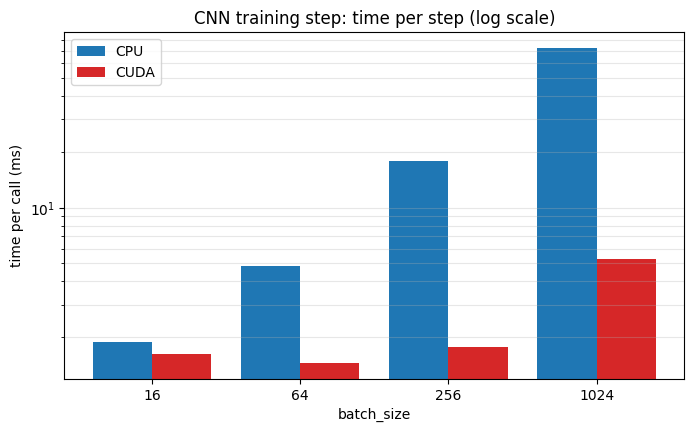

  batch    16: cpu=    1.87 ms  gpu=   1.63 ms  speedup=   1.2x
  batch    64: cpu=    4.86 ms  gpu=   1.46 ms  speedup=   3.3x
  batch   256: cpu=   17.96 ms  gpu=   1.78 ms  speedup=  10.1x
  batch  1024: cpu=   72.76 ms  gpu=   5.27 ms  speedup=  13.8x


In [6]:
# Benchmark one training step of the small CNN across batch sizes.
from nn_textbook.models import make_small_cnn

batch_sizes = [16, 64, 256, 1024]
step_records = benchmark.benchmark_training_step(
    make_model=lambda: make_small_cnn(n_classes=10, in_channels=1),
    input_shape=(1, 28, 28),
    n_classes=10,
    batch_sizes=batch_sizes,
    devices=devices,
    n_iters=10,
)

plotting.plot_benchmark(step_records, x_key="batch_size",
                        title="CNN training step: time per step (log scale)")
plt.show()

step_table = benchmark.speedup_table(step_records, x_key="batch_size")
for row in step_table:
    if "speedup" in row and row["speedup"]:
        print(f"  batch {row['batch_size']:>5}: cpu={row['cpu_ms']:8.2f} ms  "
              f"gpu={row['gpu_ms']:7.2f} ms  speedup={row['speedup']:6.1f}x")
    else:
        print(f"  batch {row['batch_size']:>5}: cpu={row['cpu_ms']:8.2f} ms")

## 5. Transformer ブロックでも測る

アーキテクチャによって GPU 優位の出方は変わります。
注意機構は行列積のかたまりなので、CNN より GPU が効きやすい代表例です。
07 章の Transformer ブロックに小さな分類ヘッドを付け、学習ステップを計測します。

In [7]:
# One training step of a transformer block classifier across batch sizes.
from nn_textbook.models import make_transformer_block

class BlockClassifier(torch.nn.Module):
    def __init__(self, d_model=128, n_heads=4, n_classes=10):
        super().__init__()
        self.block = make_transformer_block(d_model=d_model, n_heads=n_heads, d_ff=4 * d_model)
        self.head = torch.nn.Linear(d_model, n_classes)

    def forward(self, x):                      # x: (B, T, d_model)
        h, _ = self.block(x)
        return self.head(h.mean(dim=1))        # mean-pool over tokens -> (B, n_classes)


tf_records = benchmark.benchmark_training_step(
    make_model=BlockClassifier,
    input_shape=(64, 128),                     # T=64 tokens, d_model=128
    n_classes=10,
    batch_sizes=[16, 64, 256],
    devices=devices,
    n_iters=10,
)
for row in benchmark.speedup_table(tf_records, x_key="batch_size"):
    if "speedup" in row and row["speedup"]:
        print(f"  batch {row['batch_size']:>4}: cpu={row['cpu_ms']:8.2f} ms  "
              f"gpu={row['gpu_ms']:6.2f} ms  speedup={row['speedup']:6.1f}x")
    else:
        print(f"  batch {row['batch_size']:>4}: cpu={row['cpu_ms']:8.2f} ms")

  batch   16: cpu=    6.31 ms  gpu=  2.22 ms  speedup=   2.8x
  batch   64: cpu=   19.78 ms  gpu=  2.37 ms  speedup=   8.4x
  batch  256: cpu=   72.92 ms  gpu=  4.95 ms  speedup=  14.7x


## 6. throughput で見る(サンプル/秒)

「1 ステップの時間」だけでなく、**単位時間に何サンプル処理できるか**(throughput)で見ると、
大バッチで GPU が効く様子がより直感的です。

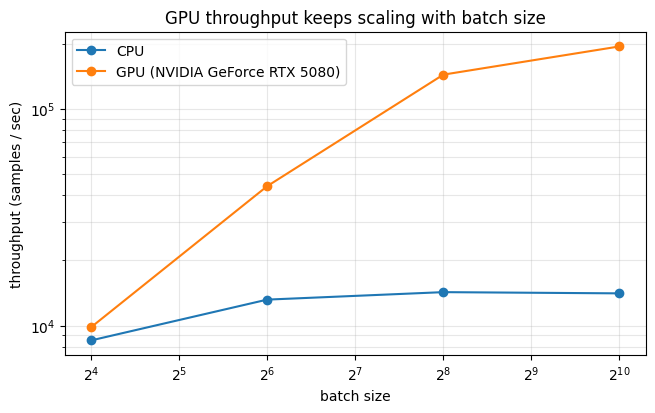

In [8]:
# Throughput = samples processed per second = batch_size / step_time.
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for device in devices:
    xs, ys = [], []
    for r in step_records:
        if r["device"] == device:
            xs.append(r["batch_size"])
            ys.append(r["batch_size"] / (r["ms"] / 1000))   # samples per second
    ax.plot(xs, ys, "o-", label=benchmark.device_label(device))
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("batch size"); ax.set_ylabel("throughput (samples / sec)")
ax.set_title("GPU throughput keeps scaling with batch size"); ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()

## 7. 教材の Notebook で GPU を使うには

本編の Notebook(04〜09 章)は **環境変数ひとつで GPU 実行に切り替え** られます。

```bash
NN_TEXTBOOK_GPU=1 uv run jupyter lab analytics/neural_net/notebooks/
# または一括再実行:
NN_TEXTBOOK_GPU=1 uv run jupyter nbconvert --to notebook --execute --inplace notebooks/05_*.ipynb
```

各 Notebook の冒頭セルが次のように分岐します。

```python
device = get_device() if os.environ.get("NN_TEXTBOOK_GPU") == "1" else torch.device("cpu")
```

リポジトリにコミットされた出力は **CPU 実行で固定** しています
(seed を固定しても CPU/GPU で数値は完全一致しないため、再現性を優先)。

In [9]:
# get_device() picks the GPU automatically when one is present.
from nn_textbook.training import get_device

auto_device = get_device()
print("get_device() selected:", benchmark.device_label(str(auto_device)))

get_device() selected: GPU (NVIDIA GeForce RTX 5080)


## 8. まとめ — GPU を使うべきとき

| 状況 | 速いのは |
|---|---|
| 大きな行列積・畳み込み・注意 | **GPU**(並列度が活きる) |
| 大バッチ学習 | **GPU**(throughput が伸びる) |
| 半精度が使える場面 | **GPU**(Tensor Core でさらに加速) |
| 小さなモデル・小バッチ | しばしば **CPU**(オーバーヘッドが勝つ) |
| 単発の小さな演算・前処理 | **CPU**(転送・起動の固定費を避ける) |
| デバッグ・少量データ | **CPU**(起動が速く手軽) |

**要点**: GPU は「大量の同種計算」を一気に片づける装置。
モデルとバッチが大きいほど効き、小さいうちは CPU の方が速いことも多い。
だから本教材のような小規模な実験は CPU で十分で、
大規模化したときに初めて GPU が必須になります。

```{admonition} 実社会では
:class: important
「いつ GPU を使うか」は計算規模で決まります。

- 大きい：行列積・畳み込み・注意、大バッチ学習、半精度（Tensor Core）→ GPU。
- 小さい：小モデル・小バッチ・単発演算・前処理・デバッグ → しばしば CPU の方が速い。
- 混合精度（AMP）でメモリ半減＋高速化が実務標準。本教材の小規模実験は CPU で十分。
```

## 9. 補足: 計測を誤るとどうなるか(同期忘れ)

最後に、§1 で触れた「同期忘れ」の実演です。
`torch.cuda.synchronize()` を呼ばずに GPU を計測すると、カーネルの完了を待たずタイマーが止まり、
**実際よりずっと速い**(誤った)数値が出ます。

> このセルは重い CUDA 計算を行うため、CPU のスレッド状態に影響します。
> 上のベンチマークを汚染しないよう、意図的にノートブックの末尾に置いています。

In [10]:
# What goes wrong WITHOUT synchronization (only meaningful with a GPU).
import time

if "cuda" in devices:
    a = torch.randn(4096, 4096, device="cuda")
    b = torch.randn(4096, 4096, device="cuda")

    for _ in range(5):      # warmup
        _ = a @ b
    torch.cuda.synchronize()

    # Naive (wrong): no sync -> measures only kernel-launch time, not the work.
    t0 = time.perf_counter()
    for _ in range(20):
        c = a @ b
    naive = (time.perf_counter() - t0) / 20

    # Correct: synchronize before stopping the timer.
    t0 = time.perf_counter()
    for _ in range(20):
        c = a @ b
    torch.cuda.synchronize()
    correct = (time.perf_counter() - t0) / 20

    print(f"naive (no sync) : {1000 * naive:8.3f} ms  <- misleadingly small")
    print(f"correct (synced): {1000 * correct:8.3f} ms  <- the real time")
else:
    print("no GPU: skipping the synchronization demo")

naive (no sync) :    0.040 ms  <- misleadingly small
correct (synced):   16.705 ms  <- the real time


## 10. Exercises

1. `benchmark_matmul` を 16384 まで伸ばし、GPU メモリの限界とスピードアップの上限を探れ
   (`torch.cuda.OutOfMemoryError` の扱いに注意)。
2. CNN のチャネル数を 4 倍にした重いモデルで学習ステップを計測し、GPU 優位がどう変わるか調べよ。
3. 先頭の `CPU_THREADS` を 1 / 4 / 8 / 20 と変え、CPU 側の時間がどう変わるか観察せよ
   (小さな演算ほどスレッド数の影響が大きい)。
4. `bfloat16`(`dtype=torch.bfloat16`)でも §3 を計測し、fp16 と比較せよ。
5. §5 の Transformer ブロックで系列長 T を 64 → 256 に伸ばし、$O(T^2)$ の注意が
   計測時間にどう現れるか確認せよ。
6. (発展)`NN_TEXTBOOK_GPU=1` で 05 章(CNN)を実行し、CPU 実行との所要時間を比べよ。